In [4]:
import numpy as np
from scipy.special import eval_legendre
from scipy.integrate import quad

# Function to compute the Gaunt coefficient for given n, m, l
def gaunt_coefficient(n, m, l):
    # Define the integrand: P_n(x) * P_m(x) * P_l(x)
    def integrand(x):
        return eval_legendre(n, x) * eval_legendre(m, x) * eval_legendre(l, x)

    # Compute the integral of the product over [-1, 1]
    result, _ = quad(integrand, -1, 1)
    return result

# Generate Gaunt coefficients for n, m in [0, 2] and l in [0, 4]
gaunt_coeffs = {}

for n in range(3):  # n = 0, 1, 2
    for m in range(3):  # m = 0, 1, 2
        for l in range(5):  # l = 0, 1, 2, 3, 4
            # Check if the Gaunt coefficient is nonzero based on the selection rules
            if abs(n - m) <= l <= (n + m):
                gaunt_coeffs[(n, m, l)] = gaunt_coefficient(n, m, l)/(2/(2*l+1))

# Print the Gaunt coefficients
for (n, m, l), coeff in gaunt_coeffs.items():
    print(f"Gaunt({n}, {m}, {l}) = {coeff:.6f}")


Gaunt(0, 0, 0) = 1.000000
Gaunt(0, 1, 1) = 1.000000
Gaunt(0, 2, 2) = 1.000000
Gaunt(1, 0, 1) = 1.000000
Gaunt(1, 1, 0) = 0.333333
Gaunt(1, 1, 1) = 0.000000
Gaunt(1, 1, 2) = 0.666667
Gaunt(1, 2, 1) = 0.400000
Gaunt(1, 2, 2) = -0.000000
Gaunt(1, 2, 3) = 0.600000
Gaunt(2, 0, 2) = 1.000000
Gaunt(2, 1, 1) = 0.400000
Gaunt(2, 1, 2) = -0.000000
Gaunt(2, 1, 3) = 0.600000
Gaunt(2, 2, 0) = 0.200000
Gaunt(2, 2, 1) = -0.000000
Gaunt(2, 2, 2) = 0.285714
Gaunt(2, 2, 3) = -0.000000
Gaunt(2, 2, 4) = 0.514286


In [5]:
import numpy as np
from numpy import sqrt
from scipy.special import eval_legendre
from scipy.integrate import quad
class Integrand:
    def __init__(self):
        self.mnk=[0,0,0]
        # Degrees of the polynomials
    # Define the product of Legendre polynomials
    def integrand(self,x):
        m,n,k=self.mnk
        return eval_legendre(m, x) * eval_legendre(n, x) * eval_legendre(k, x)
def integrand(x):
    n=m=2
    return eval_legendre(n, x) * eval_legendre(m, x)/(2/(2*n+1))
print(quad(integrand, -1, 1)[0])
# Compute the integral
H = np.zeros((3,3,5),dtype=float)
I = Integrand()
for m in range(3):
    for n in range(3):
        for k in range(5):
            I.mnk=[m,n,k]
            H[m,n,k] = quad(I.integrand, -1, 1)[0]*(2*k+1)/2
if False:
    H[0,0,0]=H[0,1,1]=H[1,0,1]=1.
    H[1,0,0]=H[1,1,1]=H[1,2,2]=H[1,2,0]=H[2,1,0]=0.
    H[1,1,2]=2/3
    H[1,1,0]=H[1,2,1]=H[2,1,1]=1/3
    H[1,2,3]=H[2,1,3]=3/5
print(H[0,0,0])
print(H[1,1,0])
print(H[2,2,0])
print(H[1,1,2])
print(H[0, 2, 2])

1.0
1.0
0.3333333333333333
0.2
0.6666666666666666
1.0


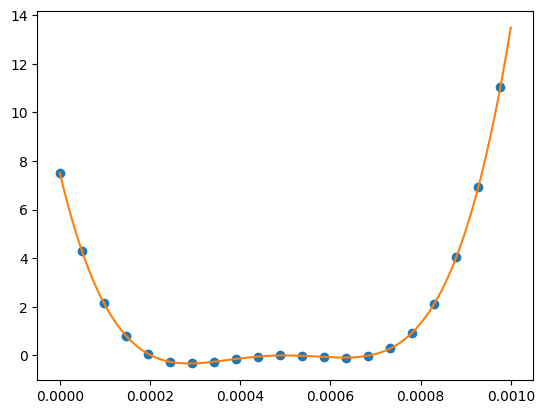

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval
from scipy.special import legendre

a=np.array([0.5,1.,3.])
b=np.array([1.,0.,2.])
c=np.zeros(5)
x = np.linspace(-1., 1., 50)
for m in range(3):
    for k in range(3):
        #plt.plot(x,  legendre(m)(x)* legendre(k)(x),'-')
        h = np.zeros(50,dtype=float)
        for n in range(abs(m-k),m+k+1):
            h += H[m,k,n]*legendre(n)(x)
        #plt.plot(x,  h,'+',markevery=4)
for n in range(abs(m-k),m+k+1):
    for m in range(3):
        for k in range(3):
            c[n]+= a[m]*b[k]*H[m,k,n]
#print(c)
L=1e-3
Nx=2048
x = np.linspace(0.0, L, Nx)
x_scaled = 2 * (x - x.min()) / (x.max() - x.min()) - 1
plt.plot(x, legval(x_scaled, c,tensor=False),'o',markevery=100) #np.sin(np.pi * x / Lx)  # W/m²
d = legval(x_scaled, a,tensor=False)*legval(x_scaled, b,tensor=False)
plt.plot(x, d,'-') #np.sin(np.pi * x / Lx)  # W/m²
plt.show()